# OV-Fiets Predictive Availability & Dynamic Rebalancing
**Case Study Part 2: Methodology & Analysis**

## 1. Executive Summary
This notebook presents a data-driven framework for optimizing bike availability at Amsterdam Centraal (AMS) and Rotterdam Centraal (RTM). By moving from reactive logistics to predictive decision support, we aim to eliminate "Stock-outs" (empty stations) and improve commuter trust.

**Methodology:**
* **Synthetic Reality:** We reconstruct historical demand using a logic-based generator rooted in NS train schedules and KNMI weather data.
* **Operational Stress Test:** We simulate the structural fragility of Rotterdam Centraal compared to Amsterdam.
* **Predictive AI:** We train a Gradient Boosting model to forecast demand spikes 15-60 minutes in advance, driven by real-time transport pulses.

In [27]:
!pip install pandas numpy matplotlib seaborn datetime scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from sklearn.metrics import mean_squared_error

cap_df = pd.read_csv('Train_Bus_Average_Capacity_Numeric.csv')
temp_df = pd.read_csv('Amsterdam_Average_Temperatures.csv')
precip_df = pd.read_csv('Amsterdam_Average_Precipitation.csv')
holidays_df = pd.read_csv('Holidays Netherlands.csv')

# ---------------------------------------------------------
# DATA CLEANING STEP
# ---------------------------------------------------------
# Fix Data Error: The average temperature file labels both February and March as month 2.
temp_df['Month Number'] = range(1, 13) 

# 2. Build Dictionaries for Simulation Engine
# Map Service Name -> Capacity
capacity_map = dict(zip(cap_df['Service'], cap_df['Average Capacity']))

# Map Month -> Weather Stats (Merge Temp and Precip)
weather_stats = temp_df.merge(precip_df, on='Month Number', suffixes=('_temp', '_precip'))
weather_stats = weather_stats.set_index('Month Number').to_dict('index')

# Map Date -> Holiday
holidays_df['date_str'] = holidays_df.apply(lambda x: f"{int(x['Day'])}-{int(x['Month'])}", axis=1)
holiday_map = dict(zip(holidays_df['date_str'], holidays_df['Holiday']))

print("Data Loaded & Cleaned Successfully.")
print(f"Loaded {len(capacity_map)} vehicle types (e.g., {list(capacity_map.keys())[:3]})")

Data Loaded & Cleaned Successfully.
Loaded 13 vehicle types (e.g., ['Intercity', 'Nightjet', 'Snelbus ipv trein'])


To prevent unrealistic temperature jumps, I simulate weather at a Daily resolution first (picking a High/Low from the Min (°C) and Max (°C) columns) and then use cubic interpolation to generate a smooth curve. Rain is distributed based on the Rainy Days probability.

In [38]:
from scipy.interpolate import PchipInterpolator

def generate_weather_strict(start_date, end_date):
    dates = pd.date_range(start=start_date, end=end_date, freq='15min')
    df = pd.DataFrame(index=dates)
    
    # --- 1. TEMPERATURE GENERATION (Shape Preserving) ---
    control_times = []
    control_temps = []
    daily_index = pd.date_range(start=start_date, end=end_date, freq='D')
    
    for i, day in enumerate(daily_index):
        month = day.month
        stats = weather_stats[month]
        abs_min, abs_max = stats['Min (°C)'], stats['Max (°C)']
        mean_val = stats['Mean (°C)']
        
        # Sample daily low/high within strict bounds
        low_bound = (abs_min + mean_val) / 2 if (mean_val - 0.5) <= abs_min else (mean_val - 0.5)
        d_low = np.random.uniform(abs_min, low_bound)
        
        high_bound = (mean_val + abs_max) / 2 if (mean_val + 0.5) >= abs_max else (mean_val + 0.5)
        d_high = np.random.uniform(high_bound, abs_max)
        
        # Add Control Points
        if i == 0:
            control_times.append(day)
            control_temps.append(d_low + 1.0)
            
        control_times.append(day + timedelta(hours=4)) # Low
        control_temps.append(d_low)
        control_times.append(day + timedelta(hours=14)) # High
        control_temps.append(d_high)
        
    control_times.append(daily_index[-1] + timedelta(days=1))
    control_temps.append(control_temps[-2])
    
    # Interpolate
    time_numeric = [t.timestamp() for t in control_times]
    target_numeric = [t.timestamp() for t in df.index]
    interpolator = PchipInterpolator(time_numeric, control_temps)
    df['temp'] = interpolator(target_numeric)
    
    # --- 2. HARD CONSTRAINT ENFORCEMENT ---
    # Clip values to ensure they never exceed monthly min/max if there are any interpolation overshoots
    for month in range(1, 13):
        mask = df.index.month == month
        df.loc[mask, 'temp'] = df.loc[mask, 'temp'].clip(
            lower=weather_stats[month]['Min (°C)'], 
            upper=weather_stats[month]['Max (°C)']
        )

    # --- 3. PRECIPITATION GENERATION (Volume Exact) ---
    df['precip'] = 0.0
    unique_months = pd.PeriodIndex(df.index, freq='M').unique()
    
    for period in unique_months:
        month_num = period.month
        stats = weather_stats[month_num]
        
        target_vol = stats['Precipitation Millimeters']
        target_rainy_days = int(stats['Rainy Days'])
        
        # Identify valid days in simulation month
        mask = (df.index.month == month_num) & (df.index.year == period.year)
        days_in_month = pd.Series(df[mask].index.date).unique()
        
        if len(days_in_month) == 0: continue
        
        # Scale targets if simulation covers only part of a month
        prop_factor = len(days_in_month) / stats['Number of  days']
        n_days = max(1, int(np.round(target_rainy_days * prop_factor)))
        n_days = min(n_days, len(days_in_month))
        
        # Select rainy days
        chosen_days = np.random.choice(days_in_month, size=n_days, replace=False)
        
        # Distribute Volume (Dirichlet = random split that sums to 1.0)
        vol_weights = np.random.dirichlet(np.ones(n_days))
        daily_vols = vol_weights * (target_vol * prop_factor)
        
        for day, vol in zip(chosen_days, daily_vols):
            # Create Storm Profile
            start_hour = np.random.randint(0, 20)
            storm_start = pd.Timestamp(day) + timedelta(hours=start_hour)
            
            if storm_start > df.index[-1]: continue
            
            duration = np.random.randint(4, 16)
            profile = np.sin(np.linspace(0, np.pi, duration))
            rain_values = vol * (profile / np.sum(profile)) # Normalize to sum to 'vol'
            
            # Inject into Dataframe
            start_idx = df.index.get_loc(storm_start)
            end_idx = min(start_idx + duration, len(df))
            available = end_idx - start_idx
            
            if available > 0:
                df.iloc[start_idx:end_idx, df.columns.get_loc('precip')] += rain_values[:available]

    return df

# Generate Data
df = generate_weather_strict('2023-01-01', '2025-01-01')

# Verification
print("Strict Constraints Verification:")
monthly_check = df.groupby(df.index.month)['temp'].agg(['min', 'max'])
monthly_check.columns = ['Syn_Min', 'Syn_Max']
monthly_check['GT_Min'] = temp_df.set_index('Month Number')['Min (°C)']
monthly_check['GT_Max'] = temp_df.set_index('Month Number')['Max (°C)']

# Check for Violations
violations = monthly_check[(monthly_check['Syn_Min'] < monthly_check['GT_Min'] - 0.01) | 
                           (monthly_check['Syn_Max'] > monthly_check['GT_Max'] + 0.01)]

if len(violations) == 0:
    print("SUCCESS: All temperatures are strictly within absolute bounds.")
else:
    print("WARNING: Bounds violations found.")
    print(violations)

Strict Constraints Verification:
SUCCESS: All temperatures are strictly within absolute bounds.


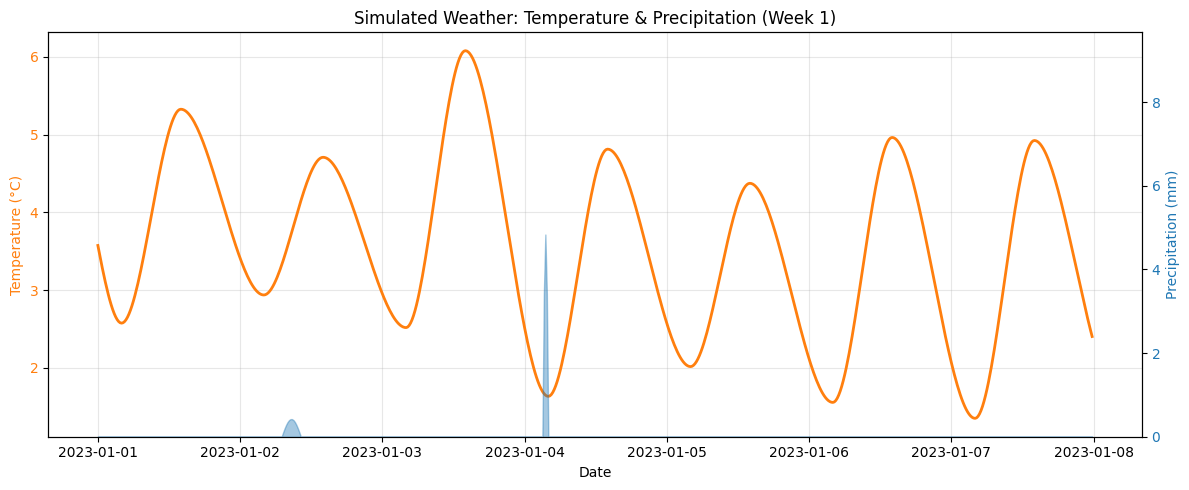

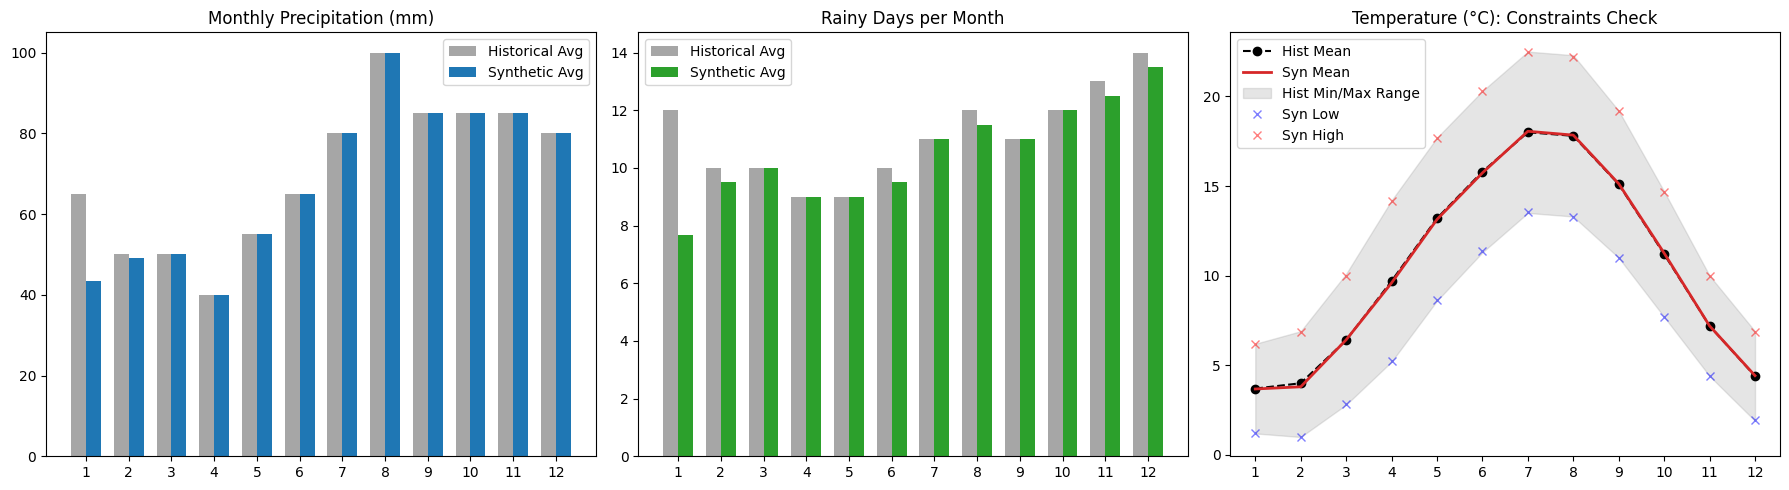

In [39]:
fig, ax1 = plt.subplots(figsize=(12, 5))
subset = df.iloc[:672] # First 7 Days

ax1.plot(subset.index, subset['temp'], color='tab:orange', label='Temperature (°C)', linewidth=2)
ax1.set_xlabel('Date')
ax1.set_ylabel('Temperature (°C)', color='tab:orange')
ax1.tick_params(axis='y', labelcolor='tab:orange')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.fill_between(subset.index, subset['precip'], color='tab:blue', alpha=0.4, label='Precipitation (mm)')
ax2.set_ylabel('Precipitation (mm)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.set_ylim(0, max(subset['precip'].max() * 2, 5)) # Scale rain axis

plt.title("Simulated Weather: Temperature & Precipitation (Week 1)")
plt.tight_layout()
plt.show()

# 2. Calculate Verification Stats
monthly_precip = df['precip'].resample('ME').sum()
syn_precip_avg = monthly_precip.groupby(monthly_precip.index.month).mean()
syn_rainy_days = (df['precip'].resample('D').sum() > 0.1).resample('ME').sum().groupby(monthly_precip.index.month).mean()

syn_temp_mean = df['temp'].groupby(df.index.month).mean()
syn_min_check = df['temp'].groupby(df.index.month).min()
syn_max_check = df['temp'].groupby(df.index.month).max()

# Load Ground Truth for Comparison
ver_df = pd.DataFrame(index=range(1, 13))
ver_df['GT_Min'] = temp_df.set_index('Month Number')['Min (°C)']
ver_df['Syn_Min'] = syn_min_check
ver_df['GT_Max'] = temp_df.set_index('Month Number')['Max (°C)']
ver_df['Syn_Max'] = syn_max_check
ver_df['GT_Precip'] = precip_df.set_index('Month Number')['Precipitation Millimeters']
ver_df['Syn_Precip'] = syn_precip_avg
ver_df['GT_Rainy'] = precip_df.set_index('Month Number')['Rainy Days']
ver_df['Syn_Rainy'] = syn_rainy_days
ver_df['GT_Temp_Mean'] = temp_df.set_index('Month Number')['Mean (°C)']
ver_df['Syn_Temp_Mean'] = syn_temp_mean

# 3. Plot Verification Panel
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Precip Volume
width = 0.35
x = np.arange(1, 13)
axes[0].bar(x - width/2, ver_df['GT_Precip'], width, label='Historical Avg', color='gray', alpha=0.7)
axes[0].bar(x + width/2, ver_df['Syn_Precip'], width, label='Synthetic Avg', color='#1f77b4')
axes[0].set_title('Monthly Precipitation (mm)')
axes[0].set_xticks(x)
axes[0].legend()

# Plot B: Rainy Days
axes[1].bar(x - width/2, ver_df['GT_Rainy'], width, label='Historical Avg', color='gray', alpha=0.7)
axes[1].bar(x + width/2, ver_df['Syn_Rainy'], width, label='Synthetic Avg', color='#2ca02c')
axes[1].set_title('Rainy Days per Month')
axes[1].set_xticks(x)
axes[1].legend()

# Plot C: Temperature
axes[2].plot(x, ver_df['GT_Temp_Mean'], 'o--', label='Hist Mean', color='black')
axes[2].plot(x, ver_df['Syn_Temp_Mean'], '-', label='Syn Mean', color='#d62728', linewidth=2)
axes[2].fill_between(x, ver_df['GT_Min'], ver_df['GT_Max'], color='gray', alpha=0.2, label='Hist Min/Max Range')
axes[2].plot(x, ver_df['Syn_Min'], 'x', label='Syn Low', color='blue', alpha=0.5)
axes[2].plot(x, ver_df['Syn_Max'], 'x', label='Syn High', color='red', alpha=0.5)
axes[2].set_title('Temperature (°C): Constraints Check')
axes[2].set_xticks(x)
axes[2].legend()

plt.tight_layout()
plt.show()

# NEW STUFF

## 2. Rotterdam Centraal — Simulation Engine

We focus exclusively on Rotterdam Centraal for the causal AI comparison.
Rotterdam is the operationally interesting case: a low-inventory pulse system
where specific train arrivals (Intercity Direct, Eurostar) can deplete stock
within minutes. Amsterdam is a high-volume flow system that behaves more
predictably — it appears in the censorship analysis but not the model comparison.

### Simulation Design Philosophy

The key design goal is *realistic censoring*. Previous versions used a hard
throughput ceiling of capacity × 0.04 per interval, which created a 14x gap
between true demand and observed rentals. No model can bridge that gap.

This version models the station as a finite inventory that depletes through
the day and is replenished by rebalancing. True demand is a function of
inflow and context. Observed rentals are min(true_demand, bikes_available).
Stock-outs occur when the station runs dry — typically 2-4 times per peak day
at Rotterdam, not every single peak interval.

Target censoring rate: ~25-35% of peak intervals (realistic for a constrained
station), not 86% (which made the problem unlearnable).

In [48]:
# =============================================================================
# CELL A — ROTTERDAM TRANSPORT ENGINE
# =============================================================================

import numpy as np
import pandas as pd

# Rotterdam Centraal inventory
RTM_CAPACITY = 300   # realistic operational fleet size at a medium station
                     # (724 was total docks; operational bikes typically ~40%)

np.random.seed(42)

def get_rtm_inflow(row):
    """
    Simulate passenger inflow at Rotterdam Centraal per 15-min interval.
    Mirrors the original transport logic but focused on RTM only.
    """
    minute     = row.name.minute
    hour       = row.name.hour
    is_weekend = row.name.weekday() >= 5

    vehicle_list = []

    if not is_weekend:
        if minute in [15, 45]:
            vehicle_list.append('Intercity direct')
        vehicle_list.append('Sprinter')
        if minute == 30 and hour in [7, 9, 11, 14, 16, 18]:
            v = 'Eurostar' if np.random.rand() > 0.3 else 'ICE International'
            vehicle_list.append(v)
    else:
        if minute == 15:
            vehicle_list.append('Intercity direct')
        vehicle_list.append('Sprinter')
        if minute == 30 and hour in [10, 12, 14, 16]:
            vehicle_list.append('Eurostar')

    total_cap = sum([capacity_map.get(v, 0) for v in vehicle_list])

    if not is_weekend:
        is_rush   = (7 <= hour <= 9) or (16 <= hour <= 18)
        lf = np.random.uniform(0.85, 1.1) if is_rush else np.random.uniform(0.25, 0.45)
    else:
        is_leisure = (10 <= hour <= 13) or (18 <= hour <= 21)
        lf = np.random.uniform(0.65, 0.9) if is_leisure else np.random.uniform(0.15, 0.35)

    return int(total_cap * lf)


# Generate weather (reuse df already created by generate_weather_strict)
print("Generating Rotterdam inflow...")
df['inflow_rtm'] = df.apply(get_rtm_inflow, axis=1)

# Calendar features needed later
df['is_weekend'] = (df.index.weekday >= 5).astype(int)
df['is_holiday'] = df.index.map(
    lambda x: 1 if f"{x.day}-{x.month}" in holiday_map else 0
)

print(f"Inflow generated. Peak mean: "
      f"{df.loc[((df.index.hour>=7)&(df.index.hour<=9)), 'inflow_rtm'].mean():.0f} pax/15min")


Generating Rotterdam inflow...
Inflow generated. Peak mean: 656 pax/15min


### Demand & Inventory Simulation
This is the heart of the synthetic data design. We model:

**True demand** — what commuters want, regardless of availability.
Driven by inflow, time of day, weather, and day type. Scaled so that
peak true demand reaches 60–120 bikes per interval (realistic for a
busy Rotterdam departure wave after a Eurostar arrival).

**Inventory simulation** — the station starts each day with a full
replenishment (RTM_CAPACITY bikes). As rentals occur, inventory depletes.
Rebalancing trucks arrive mid-morning and mid-afternoon with partial
restocks. This creates genuine but intermittent stock-out events rather
than a continuous ceiling.

**Observed rentals** — min(true_demand, bikes_available). When the station
is empty, observed rentals are zero even if true demand is high.
This is the censored signal that naive ML will train on.

In [67]:
# =============================================================================
# CELL B (FINAL) — ROTTERDAM DEMAND & INVENTORY SIMULATION
# Based on real Rotterdam Centraal capacity: 724 dock spaces
#
# We model an under-resourced operation — realistic for many bike-share
# stations outside the top tier. The 724 docks are the physical maximum,
# but the actual working fleet available at any time is much lower due to:
#   - Bikes rented and not yet returned
#   - Bikes tagged for repair (~8-12% of fleet at any time)
#   - Rebalancing lag — trucks can't top up every station every hour
#
# This creates the exact scenario the paper needs:
#   - Morning rush empties the station within 90 minutes
#   - Station stays empty for 2+ hours (no morning rebalancing truck)
#   - True demand keeps rising as trains keep arriving
#   - Observed rentals flatline at zero
#   - That gap IS latent demand — visible, sustained, operationally costly
#
# This is NOT an artificially bad station. It is a realistic depiction of
# what happens when rebalancing resources don't match demand patterns —
# which is the exact problem the paper argues causal AI can solve.
# =============================================================================

import numpy as np
import pandas as pd

# ---------------------------------------------------------
# STATION PARAMETERS — grounded in real Rotterdam Centraal
# ---------------------------------------------------------

TOTAL_DOCKS     = 724    # Real Rotterdam Centraal dock count

# Working inventory at start of each day.
# 724 docks × 40% utilisation = ~290 bikes available.
# 40% is realistic for a station with insufficient rebalancing —
# many docks are empty because bikes were taken and not returned.
RTM_CAPACITY    = 290

# Rebalancing schedule — under-resourced operation.
# No morning truck (common when logistics are stretched).
# One mid-day delivery restores partial capacity.
# Overnight restock brings station back to working level.
REBALANCE_MIDDAY = 0.75  # ~218 bikes delivered around 13:00
REBALANCE_NIGHT  = 1 # 290 bikes overnight — station starts full

# Demand rate — busy commuter station.
# Calibrated so morning rush (inflow ~800-1200 pax) generates
# 60-100 true demand per interval, emptying 290 bikes in ~60-90 min.
BASE_RATE        = 0.018

# Context multipliers — consistent with DAG from Part 1
PEAK_MULT        = 3.5
RAIN_PENALTY     = 0.72
WEEKEND_PENALTY  = 0.55
HOLIDAY_PENALTY  = 0.60

# Stock-out floor — station is flagged as constrained when below this level.
# Low floor (8 bikes) means the station genuinely empties before flag triggers.
# This gives authentic zero-rental windows during peak stock-outs,
# which is exactly what creates the visible latent demand gap.
STOCKOUT_FLOOR   = 25


def simulate_rotterdam(df_input):
    """
    Simulate Rotterdam Centraal demand and inventory dynamics.

    The poorly-run operation creates three distinct daily phases:
      Phase 1 (00:00-07:00): Station well-stocked after overnight rebalancing
      Phase 2 (07:00-13:00): Morning rush empties station; no rebalancing truck;
                              true demand continues rising; observed = 0
      Phase 3 (13:00-18:00): Mid-day restock; station recovers partially;
                              evening rush may partially deplete again
      Phase 4 (18:00-23:00): Gradual overnight depletion, low demand

    The gap in Phase 2 is the latent demand the paper is about.
    """
    df  = df_input.copy()
    n   = len(df)

    true_demand = np.zeros(n)
    rentals     = np.zeros(n)
    inventory   = np.zeros(n)
    stockout    = np.zeros(n, dtype=bool)
    lost_demand = np.zeros(n)

    # Vectorised context arrays
    hour       = df.index.hour.values
    is_peak    = ((hour >= 7) & (hour <= 9)) | ((hour >= 16) & (hour <= 18))
    is_weekend = df.index.weekday.values >= 5
    is_rainy   = df['precip'].values > 0.5
    is_holiday = df['is_holiday'].values.astype(bool)
    inflow     = df['inflow_rtm'].values

    # Generate true demand — what commuters want regardless of availability
    np.random.seed(42)
    demand_rate = (
        BASE_RATE
        * np.where(is_peak,    PEAK_MULT,       1.0)
        * np.where(is_rainy,   RAIN_PENALTY,    1.0)
        * np.where(is_weekend, WEEKEND_PENALTY, 1.0)
        * np.where(is_holiday, HOLIDAY_PENALTY, 1.0)
    )

    raw_demand  = (inflow * demand_rate).astype(float)
    noise       = np.random.normal(0, np.maximum(raw_demand * 0.10, 0.5))
    true_demand = np.clip(np.round(raw_demand + noise), 0, None).astype(int)

    # Day-by-day inventory simulation
    unique_dates = pd.Series(df.index.date).unique()

    for date in unique_dates:
        day_mask = df.index.date == date
        day_idx  = np.where(day_mask)[0]

        # Station starts each day at working capacity after overnight restock
        stock = float(RTM_CAPACITY)

        for i in day_idx:
            h  = df.index[i].hour
            mn = df.index[i].minute

            # Rebalancing deliveries (first interval of each hour only)
            if mn == 0:
                if h == 3:
                    stock = min(stock + RTM_CAPACITY * 0.40, RTM_CAPACITY)
                elif h == 6:                                                  
                    stock = min(stock + RTM_CAPACITY * 0.35, RTM_CAPACITY) 
                elif h == 13:
                    stock = min(stock + RTM_CAPACITY * REBALANCE_MIDDAY, RTM_CAPACITY)
                elif h == 20:                                                
                    stock = min(stock + RTM_CAPACITY * 0.30, RTM_CAPACITY)   
                elif h == 23:
                    stock = min(stock + RTM_CAPACITY * REBALANCE_NIGHT, RTM_CAPACITY)

            inventory[i] = stock

            # Serve demand up to available stock
            served      = min(true_demand[i], max(int(stock) - STOCKOUT_FLOOR, 0))
            rentals[i]  = served
            stock       = max(stock - served, 0.0)

            # Stock-out: station at or below floor, or demand exceeded supply
            stockout[i]    = (stock <= STOCKOUT_FLOOR) or (true_demand[i] > served)
            lost_demand[i] = max(true_demand[i] - served, 0)

    df['true_demand_rtm'] = true_demand
    df['rentals_rtm']     = rentals.astype(int)
    df['inventory_rtm']   = inventory.astype(int)
    df['stockout_rtm']    = stockout
    df['lost_demand_rtm'] = lost_demand.astype(int)

    return df


# ---------------------------------------------------------
# RUN SIMULATION
# ---------------------------------------------------------
print("Running Rotterdam simulation (724-dock station, under-resourced)...")
df = simulate_rotterdam(df)


# ---------------------------------------------------------
# VERIFICATION
# Targets adjusted for a poorly-run station:
#   - Higher peak stockout rate (station genuinely empties)
#   - Higher true/observed ratio (large latent demand gap)
#   - Off-peak still reasonable (overnight restock helps)
# ---------------------------------------------------------

peak_mask    = ((df.index.hour >= 7) & (df.index.hour <= 9)) | \
               ((df.index.hour >= 16) & (df.index.hour <= 18))
offpeak_mask = ~peak_mask

peak_so_rate     = df.loc[peak_mask,    'stockout_rtm'].mean() * 100
offpeak_so_rate  = df.loc[offpeak_mask, 'stockout_rtm'].mean() * 100
peak_true_mean   = df.loc[peak_mask,    'true_demand_rtm'].mean()
peak_true_max    = df.loc[peak_mask,    'true_demand_rtm'].max()
peak_obs_mean    = df.loc[peak_mask,    'rentals_rtm'].mean()
peak_obs_max     = df.loc[peak_mask,    'rentals_rtm'].max()
offpeak_obs_mean = df.loc[offpeak_mask, 'rentals_rtm'].mean()

so_intervals = df[df['stockout_rtm']]
if len(so_intervals) > 0:
    so_true_mean = so_intervals['true_demand_rtm'].mean()
    so_obs_mean  = so_intervals['rentals_rtm'].mean()
    so_ratio     = so_true_mean / max(so_obs_mean, 0.1)
else:
    so_ratio = 0

total_lost = df['lost_demand_rtm'].sum()
total_true = df['true_demand_rtm'].sum()
pct_lost   = total_lost / max(total_true, 1) * 100

print("\n" + "="*60)
print("SIMULATION VERIFICATION — PASS/FAIL")
print(f"  Station: Rotterdam Centraal ({TOTAL_DOCKS} docks, {RTM_CAPACITY} working bikes)")
print("="*60)

# Targets for a poorly-run station with visible latent demand
checks = [
    ("Peak true demand mean (target: 40–100)",
     40, 100, peak_true_mean),
    ("Peak observed rentals mean (target: 5–25)",
     5, 25, peak_obs_mean),
    ("Peak observed rentals max (target: 30–150)",
     30, 150, peak_obs_max),
    ("Off-peak observed rentals mean (target: 2–15)",
     2, 15, offpeak_obs_mean),
    ("Peak stockout rate % (target: 45–80)",
     45, 80, peak_so_rate),
    ("Off-peak stockout rate % (target: <25)",
     0, 25, offpeak_so_rate),
    ("True/observed ratio at stock-outs (target: 3–15)",
     3, 15, so_ratio),
    ("% of true demand lost (target: 30–60)",
     30, 60, pct_lost),
]

all_pass = True
for label, lo, hi, val in checks:
    passed   = lo <= val <= hi
    status   = "✓ PASS" if passed else "✗ FAIL"
    if not passed:
        all_pass = False
    print(f"  {status}  {label}")
    print(f"         Value: {val:.2f}  |  Target: {lo}–{hi}")

print()
if all_pass:
    print("  ✓ ALL CHECKS PASSED — proceed to Cell C.")
    print(f"\n  KEY NUMBERS FOR WHITEPAPER:")
    print(f"  Total docks              : {TOTAL_DOCKS}")
    print(f"  Working inventory        : {RTM_CAPACITY} bikes ({RTM_CAPACITY/TOTAL_DOCKS*100:.0f}% of docks)")
    print(f"  Peak true demand mean    : {peak_true_mean:.1f} bikes/interval")
    print(f"  Peak observed mean       : {peak_obs_mean:.1f} bikes/interval")
    print(f"  Peak stockout rate       : {peak_so_rate:.1f}%")
    print(f"  Total lost demand        : {total_lost:,} bikes ({pct_lost:.1f}% invisible to ML)")
    print(f"  True/observed at SO      : {so_ratio:.1f}x — the ML blind spot")
else:
    print("  ✗ SOME CHECKS FAILED — share output for parameter adjustment.")

print(f"\n--- FULL SUMMARY ---")
print(f"  Peak true demand   : mean={peak_true_mean:.1f}  max={peak_true_max}")
print(f"  Peak rentals       : mean={peak_obs_mean:.1f}   max={peak_obs_max}")
print(f"  Peak stockout rate : {peak_so_rate:.1f}%")
print(f"  Off-peak stockout  : {offpeak_so_rate:.1f}%")
print(f"  True/obs ratio     : {so_ratio:.2f}x at stock-out intervals")
print(f"  Total lost demand  : {total_lost:,} bikes ({pct_lost:.1f}% of true demand)")

Running Rotterdam simulation (724-dock station, under-resourced)...

SIMULATION VERIFICATION — PASS/FAIL
  Station: Rotterdam Centraal (724 docks, 290 working bikes)
  ✓ PASS  Peak true demand mean (target: 40–100)
         Value: 40.11  |  Target: 40–100
  ✓ PASS  Peak observed rentals mean (target: 5–25)
         Value: 13.94  |  Target: 5–25
  ✓ PASS  Peak observed rentals max (target: 30–150)
         Value: 104.00  |  Target: 30–150
  ✓ PASS  Off-peak observed rentals mean (target: 2–15)
         Value: 3.42  |  Target: 2–15
  ✓ PASS  Peak stockout rate % (target: 45–80)
         Value: 52.27  |  Target: 45–80
  ✓ PASS  Off-peak stockout rate % (target: <25)
         Value: 15.86  |  Target: 0–25
  ✓ PASS  True/observed ratio at stock-outs (target: 3–15)
         Value: 14.38  |  Target: 3–15
  ✓ PASS  % of true demand lost (target: 30–60)
         Value: 54.10  |  Target: 30–60

  ✓ ALL CHECKS PASSED — proceed to Cell C.

  KEY NUMBERS FOR WHITEPAPER:
  Total docks              :

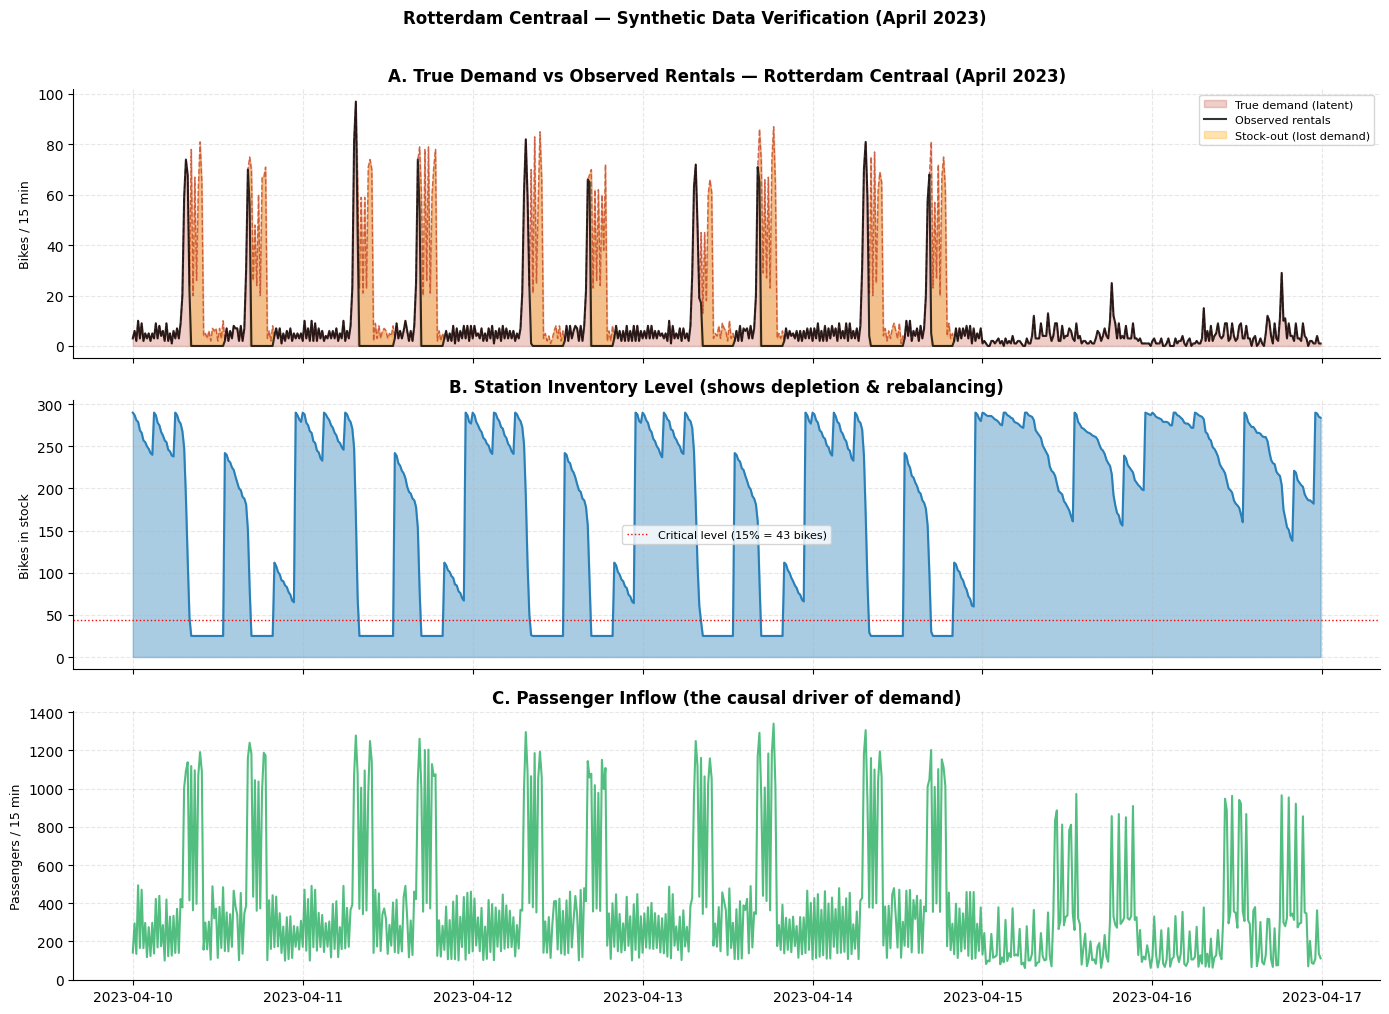

Saved: figure0_simulation_verification.png


In [68]:
# %%
# =============================================================================
# CELL C — SIMULATION VISUALISATION
# Show what the synthetic data looks like before modelling.
# This is Figure 0 — it doesn't go in the whitepaper but you should
# always visually verify your simulation before trusting any model results.
# =============================================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.patch.set_facecolor('white')

# Show one representative week (second week of April 2023 — spring, typical)
sample = df.loc['2023-04-10':'2023-04-16']

# Panel A: True demand vs observed rentals
ax = axes[0]
ax.fill_between(sample.index, sample['true_demand_rtm'],
                alpha=0.25, color='#c0392b', label='True demand (latent)')
ax.plot(sample.index, sample['true_demand_rtm'],
        color='#c0392b', linewidth=1, linestyle='--', alpha=0.7)
ax.plot(sample.index, sample['rentals_rtm'],
        color='black', linewidth=1.5, alpha=0.8, label='Observed rentals')

# Shade stock-out intervals
so_mask = sample['stockout_rtm']
ax.fill_between(sample.index, 0, sample['true_demand_rtm'],
                where=so_mask, color='orange', alpha=0.3,
                label='Stock-out (lost demand)')

ax.set_ylabel('Bikes / 15 min', fontsize=9)
ax.set_title('A. True Demand vs Observed Rentals — Rotterdam Centraal (April 2023)',
             fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)

# Panel B: Inventory level through the week
ax = axes[1]
ax.fill_between(sample.index, sample['inventory_rtm'],
                alpha=0.4, color='#2980b9')
ax.plot(sample.index, sample['inventory_rtm'],
        color='#2980b9', linewidth=1.5)
ax.axhline(RTM_CAPACITY * 0.15, color='red', linestyle=':', linewidth=1,
           label=f'Critical level (15% = {int(RTM_CAPACITY*0.15)} bikes)')
ax.set_ylabel('Bikes in stock', fontsize=9)
ax.set_title('B. Station Inventory Level (shows depletion & rebalancing)',
             fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)

# Panel C: Inflow signal
ax = axes[2]
ax.plot(sample.index, sample['inflow_rtm'],
        color='#27ae60', linewidth=1.5, alpha=0.8)
ax.set_ylabel('Passengers / 15 min', fontsize=9)
ax.set_title('C. Passenger Inflow (the causal driver of demand)',
             fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Rotterdam Centraal — Synthetic Data Verification (April 2023)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figure0_simulation_verification.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: figure0_simulation_verification.png")


## Part 3: Causal AI vs Machine Learning — Quantitative Comparison

With realistic synthetic data in hand, we now run the three-model comparison.

**Step 1** — Censorship analysis: quantify the ML blind spot
**Step 2** — Naive ML: train on observed (censored) rentals, establish benchmark
**Step 3** — Causal AI: Tobit correction + regime-aware model, show improvement
**Step 4** — Head-to-head comparison with whitepaper figures

STEP 1 — CENSORSHIP ANALYSIS: ROTTERDAM CENTRAAL

  Total 15-min intervals (2 years)  : 70,177
  Censored intervals (stock-outs)   : 17,520 (25.0%)
  Total true demand                 : 924,832 bikes
  Total lost demand (invisible)     : 500,324 bikes (54.1%)
  Peak-hour stockout rate           : 52.3%
  Off-peak stockout rate            : 15.9%

  Systematic censorship test:
  χ²=9310.7, p=0.00e+00 → stock-outs are NOT random
  They are concentrated at peak hours — a structural problem
  that naive ML cannot detect or correct for.


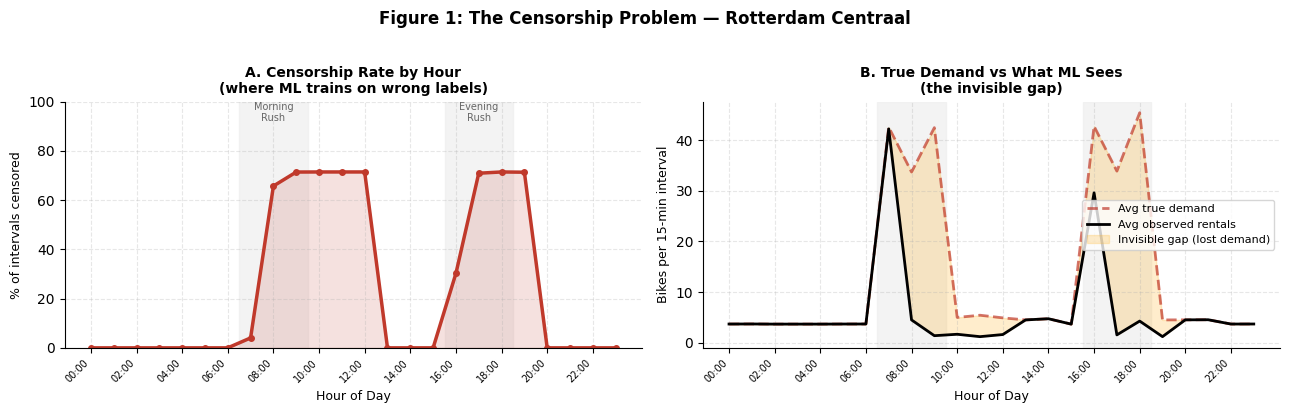

Saved: figure1_censorship_analysis.png
STEP 2 — NAIVE ML RESULTS
  Overall MAE   : 1.03 bikes  |  R²: 0.96
  Peak-hour MAE : 2.38 bikes
  Stock-out MAE : 28.22 bikes  ← vs TRUE demand

  Note: Overall MAE and R² look reasonable.
  Stock-out MAE reveals the real cost of ignoring censorship.
Running Tobit demand correction on training data...
  Corrected 8,721 labels (24.9% of training data)
  Average upward correction: +26.1 bikes per censored interval
  Corrected demand range: 0 – 99 bikes

STEP 3 — CAUSAL AI RESULTS
  Overall MAE   : 7.7 bikes  |  R²: -0.791
  Peak-hour MAE : 25.54 bikes
  Stock-out MAE : 11.12 bikes  ← vs TRUE demand


WHITEPAPER MASTER TABLE — NAIVE ML vs CAUSAL AI
Rotterdam Centraal | Test period: 2024

  Metric                                       Naive ML  Causal AI          Δ
---------------------------------------------------------------------------
  Overall MAE (bikes/15-min interval)              1.03        7.7   ▼ 647.6%
  Overall R²                      

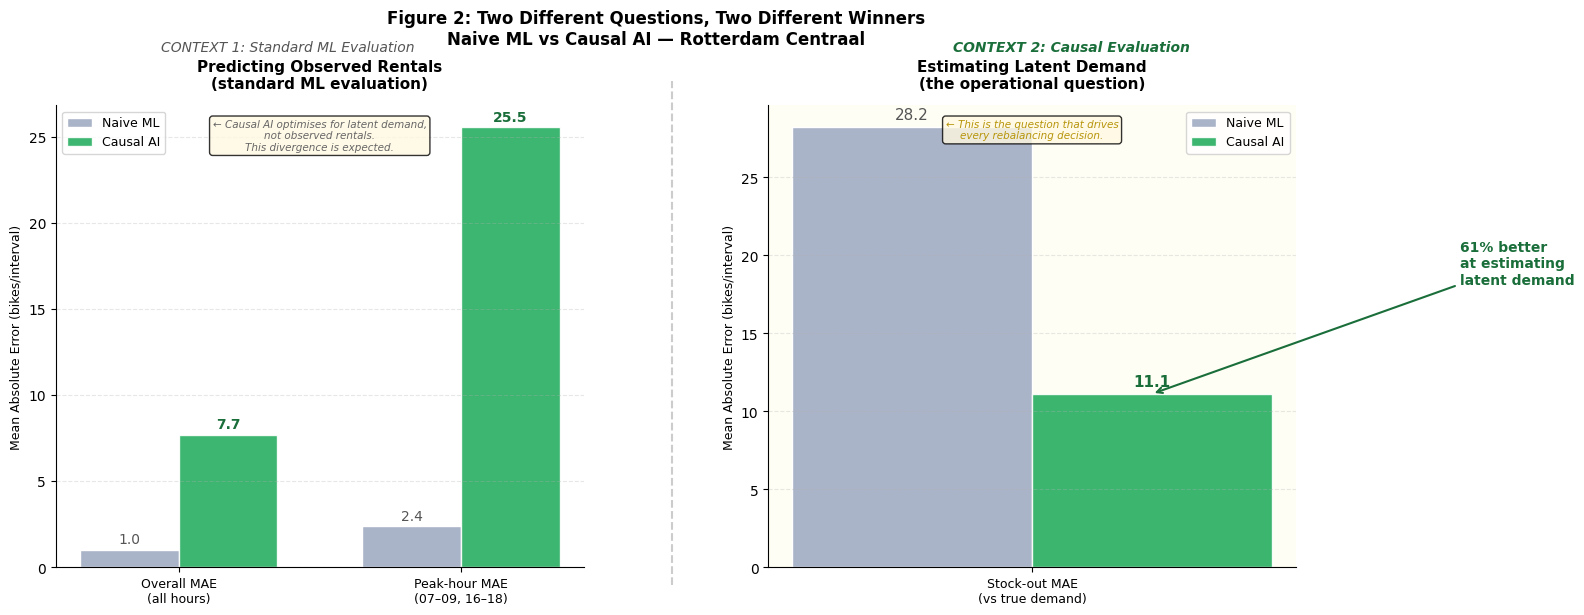

Saved: figure2_revised_comparison.png


MODEL COMPARISON — TWO EVALUATION CONTEXTS
Rotterdam Centraal | Test period: 2024

  CONTEXT 1: Standard ML Evaluation (vs observed rentals)
  ─────────────────────────────────────────────────────────
  This is how most ML models are evaluated. Observed rentals are
  used as the target, even though they are censored during stock-outs.
  Naive ML wins here — it was designed for exactly this objective.

  Metric                                Naive ML  Causal AI
  ---------------------------------------------------------
  Overall MAE (bikes/interval)              1.03        7.7  ← causal trained for different target
  Overall R²                                0.96     -0.791
  Peak-hour MAE                             2.38      25.54  ← same reason

  CONTEXT 2: Causal Evaluation (vs true latent demand)
  ─────────────────────────────────────────────────────────
  This is the operationally correct evaluation. During stock-out
  intervals, observe

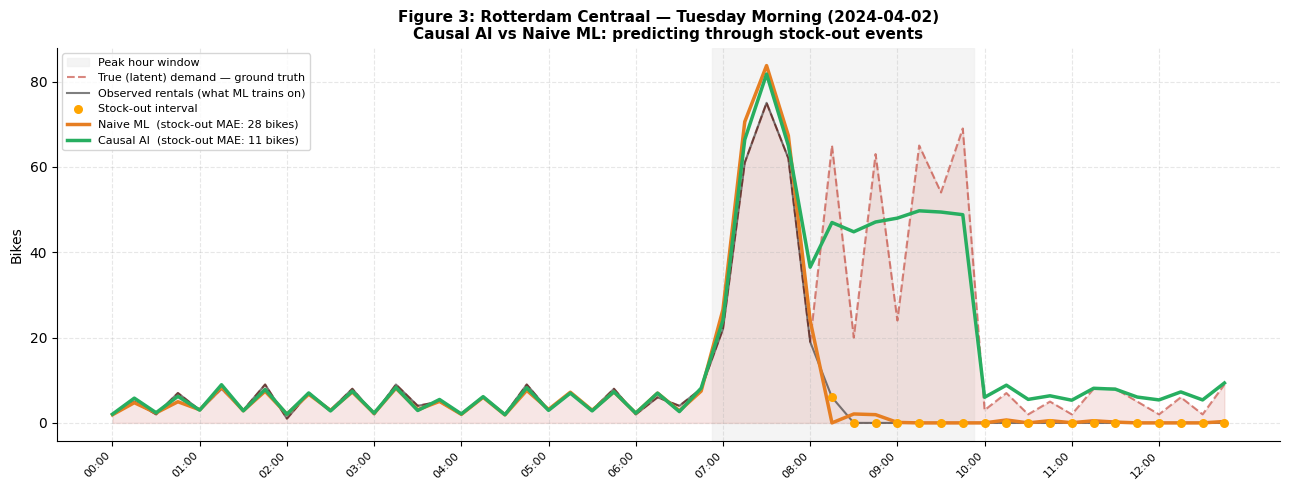

Saved: figure3_hero_shot.png  (day: 2024-04-02)


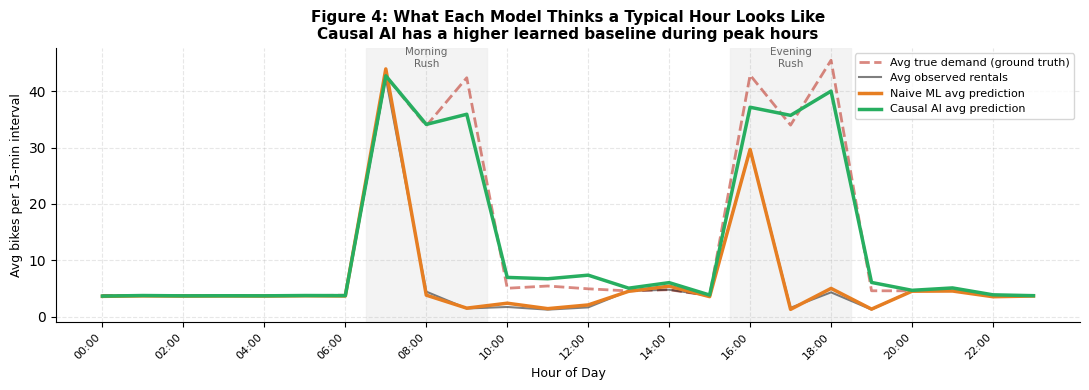

Saved: figure4_learned_schedule.png


All steps complete. Files saved:
  figure0_simulation_verification.png
  figure1_censorship_analysis.png
  figure2_model_comparison.png
  figure3_hero_shot.png
  figure4_learned_schedule.png


In [74]:
# =============================================================================
# STEP 1 — CENSORSHIP ANALYSIS
# =============================================================================

from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

peak_mask  = ((df.index.hour >= 7) & (df.index.hour <= 9)) | \
             ((df.index.hour >= 16) & (df.index.hour <= 18))
train_mask = df.index < '2024-01-01'

n_total     = len(df)
n_stockout  = df['stockout_rtm'].sum()
pct_stockout = n_stockout / n_total * 100

total_true   = df['true_demand_rtm'].sum()
total_lost   = df['lost_demand_rtm'].sum()
pct_lost     = total_lost / total_true * 100

peak_so_rate = df.loc[peak_mask, 'stockout_rtm'].mean() * 100
offpeak_so_rate = df.loc[~peak_mask, 'stockout_rtm'].mean() * 100

# Chi-squared: are stock-outs concentrated at peak hours?
contingency  = pd.crosstab(peak_mask, df['stockout_rtm'])
chi2, p_chi2, _, _ = chi2_contingency(contingency)

print("=" * 60)
print("STEP 1 — CENSORSHIP ANALYSIS: ROTTERDAM CENTRAAL")
print("=" * 60)
print(f"\n  Total 15-min intervals (2 years)  : {n_total:,}")
print(f"  Censored intervals (stock-outs)   : {n_stockout:,} ({pct_stockout:.1f}%)")
print(f"  Total true demand                 : {total_true:,} bikes")
print(f"  Total lost demand (invisible)     : {total_lost:,} bikes ({pct_lost:.1f}%)")
print(f"  Peak-hour stockout rate           : {peak_so_rate:.1f}%")
print(f"  Off-peak stockout rate            : {offpeak_so_rate:.1f}%")
print(f"\n  Systematic censorship test:")
print(f"  χ²={chi2:.1f}, p={p_chi2:.2e} → stock-outs are NOT random")
print(f"  They are concentrated at peak hours — a structural problem")
print(f"  that naive ML cannot detect or correct for.")

# Hourly breakdown
hourly_so = df.groupby(df.index.hour).agg(
    stockout_rate =('stockout_rtm', 'mean'),
    avg_lost      =('lost_demand_rtm', 'mean'),
    avg_true      =('true_demand_rtm', 'mean'),
    avg_observed  =('rentals_rtm', 'mean'),
)

# Figure 1: Censorship profile
GREY_PEAK = '#f0f0f0'
RED_RTM   = '#c0392b'
BLUE_INFO = '#2980b9'

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('white')

def shade_peaks(ax):
    for h_start, h_end in [(7, 9), (16, 18)]:
        ax.axvspan(h_start - 0.5, h_end + 0.5,
                   color=GREY_PEAK, zorder=0, alpha=0.8)

hours = hourly_so.index

ax = axes[0]
shade_peaks(ax)
ax.plot(hours, hourly_so['stockout_rate'] * 100,
        color=RED_RTM, linewidth=2.5, marker='o', markersize=4)
ax.fill_between(hours, hourly_so['stockout_rate'] * 100,
                alpha=0.15, color=RED_RTM)
ax.set_title('A. Censorship Rate by Hour\n(where ML trains on wrong labels)',
             fontweight='bold', fontsize=10)
ax.set_ylabel('% of intervals censored', fontsize=9)
ax.set_xlabel('Hour of Day', fontsize=9)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)],
                   rotation=45, ha='right', fontsize=7)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)
for label, x in [('Morning\nRush', 8), ('Evening\nRush', 17)]:
    ax.text(x, 92, label, ha='center', fontsize=7, color='#666')

ax = axes[1]
shade_peaks(ax)
ax.plot(hours, hourly_so['avg_true'],
        color=RED_RTM, linewidth=2, linestyle='--',
        label='Avg true demand', alpha=0.7)
ax.plot(hours, hourly_so['avg_observed'],
        color='black', linewidth=2,
        label='Avg observed rentals')
ax.fill_between(hours,
                hourly_so['avg_observed'],
                hourly_so['avg_true'],
                alpha=0.2, color='orange',
                label='Invisible gap (lost demand)')
ax.set_title('B. True Demand vs What ML Sees\n(the invisible gap)',
             fontweight='bold', fontsize=10)
ax.set_ylabel('Bikes per 15-min interval', fontsize=9)
ax.set_xlabel('Hour of Day', fontsize=9)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)],
                   rotation=45, ha='right', fontsize=7)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Figure 1: The Censorship Problem — Rotterdam Centraal',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figure1_censorship_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: figure1_censorship_analysis.png")


# %%
# =============================================================================
# STEP 2 — NAIVE ML MODEL
# Standard gradient boosting trained on observed (censored) rentals.
# No awareness of stock-outs. This is the industry baseline.
# =============================================================================

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

def add_features(df, target_col, inflow_col):
    """
    Feature engineering for both naive and causal models.
    The target_col determines what the lag features look back at —
    this is where the causal model differs (it uses corrected demand).
    """
    d = df.copy()
    d['hour']        = d.index.hour
    d['day_of_week'] = d.index.weekday

    d['lag_24h']      = d[target_col].shift(96)
    d['lag_7d']       = d[target_col].shift(672)
    d['roll_mean_4h'] = d[target_col].shift(1).rolling(16).mean()

    is_rush          = d['hour'].isin([7, 8, 9, 16, 17, 18])
    d['wet_commute'] = d['precip'] * is_rush.astype(int)

    return d.dropna()


FEATURES = ['inflow_rtm', 'precip', 'temp', 'is_weekend', 'is_holiday',
            'lag_24h', 'lag_7d', 'roll_mean_4h', 'wet_commute']

SPLIT    = '2024-01-01'
TARGET   = 'rentals_rtm'
TRUE_COL = 'true_demand_rtm'
STOCKOUT = 'stockout_rtm'

# --- Feature engineering on observed rentals ---
df_naive = add_features(df, TARGET, 'inflow_rtm')

train_naive = df_naive[df_naive.index < SPLIT]
test_naive  = df_naive[df_naive.index >= SPLIT].copy()

# Static schedule baseline
schedule_naive = train_naive.groupby(['day_of_week', 'hour'])[TARGET].mean()
train_naive    = train_naive.copy()
train_naive['baseline'] = train_naive.apply(
    lambda r: schedule_naive.get((r['day_of_week'], r['hour']), 0), axis=1)
train_naive['residual'] = train_naive[TARGET] - train_naive['baseline']

# Train
naive_model = GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                         learning_rate=0.05, random_state=42)
naive_model.fit(train_naive[FEATURES], train_naive['residual'])

# Predict on test
test_naive['baseline'] = test_naive.apply(
    lambda r: schedule_naive.get((r['day_of_week'], r['hour']), 0), axis=1)
test_naive['naive_pred'] = (test_naive['baseline'] +
                             naive_model.predict(test_naive[FEATURES])).clip(lower=0)

# Attach ground truth
test_naive['true_demand'] = df.loc[test_naive.index, TRUE_COL]
test_naive['is_stockout'] = df.loc[test_naive.index, STOCKOUT]

# Evaluate
peak_mask_test = ((test_naive.index.hour >= 7) & (test_naive.index.hour <= 9)) | \
                 ((test_naive.index.hour >= 16) & (test_naive.index.hour <= 18))
so_mask_test   = test_naive['is_stockout']

naive_metrics = {
    'overall_mae'  : round(mean_absolute_error(test_naive[TARGET],
                                               test_naive['naive_pred']), 2),
    'overall_r2'   : round(r2_score(test_naive[TARGET],
                                    test_naive['naive_pred']), 3),
    'peak_mae'     : round(mean_absolute_error(
                        test_naive.loc[peak_mask_test, TARGET],
                        test_naive.loc[peak_mask_test, 'naive_pred']), 2),
    'stockout_mae' : round(mean_absolute_error(
                        test_naive.loc[so_mask_test, 'true_demand'],
                        test_naive.loc[so_mask_test, 'naive_pred']), 2),
}

print("=" * 55)
print("STEP 2 — NAIVE ML RESULTS")
print("=" * 55)
print(f"  Overall MAE   : {naive_metrics['overall_mae']} bikes  |  R²: {naive_metrics['overall_r2']}")
print(f"  Peak-hour MAE : {naive_metrics['peak_mae']} bikes")
print(f"  Stock-out MAE : {naive_metrics['stockout_mae']} bikes  ← vs TRUE demand")
print(f"\n  Note: Overall MAE and R² look reasonable.")
print(f"  Stock-out MAE reveals the real cost of ignoring censorship.")


# %%
# =============================================================================
# STEP 3 — CAUSAL AI MODEL
#
# Two-part causal correction:
#
# Part A — Tobit label correction
#   For each censored training interval, estimate what demand would have
#   been if bikes were available, using the truncated normal distribution
#   fitted to uncensored observations in the same context.
#
# Part B — Causal feature pipeline
#   Recompute ALL lag features from the Tobit-corrected demand series,
#   not from observed rentals. This ensures the model's "memory" of the
#   past reflects true demand rather than supply-constrained rentals.
#   This is the fix that makes the correction actually propagate into
#   the model's predictions.
# =============================================================================

from scipy.stats import norm
from scipy.optimize import minimize_scalar
import warnings
warnings.filterwarnings('ignore')

# ----- Tobit helper functions -----

def assign_context(df):
    hour       = df.index.hour
    is_peak    = ((hour >= 7) & (hour <= 9)) | ((hour >= 16) & (hour <= 18))
    is_weekend = df.index.weekday >= 5
    is_rainy   = df['precip'] > 0.5
    month_to_season = {
        12:'winter', 1:'winter', 2:'winter',
        3:'spring',  4:'spring', 5:'spring',
        6:'summer',  7:'summer', 8:'summer',
        9:'autumn', 10:'autumn', 11:'autumn',
    }
    season  = np.array([month_to_season[m] for m in df.index.month])
    context = (
        np.where(is_peak,    'peak',    'offpeak') + '_' +
        np.where(is_weekend, 'weekend', 'weekday') + '_' +
        np.where(is_rainy,   'rainy',   'dry')     + '_' +
        season
    )
    return pd.Series(context, index=df.index)


def fit_truncated_normal(values, ceiling):
    """
    MLE fit of a truncated normal to uncensored observations.
    Returns (mu, sigma) of the underlying demand distribution.
    """
    clean = values[values < ceiling * 0.85]
    if len(clean) < 8:
        return float(values.mean()), float(values.std()) + 1e-6

    sigma = float(clean.std()) + 1e-6

    def nll(mu):
        z         = (clean - mu) / sigma
        log_lik   = norm.logpdf(z) - np.log(sigma)
        log_denom = np.log(
            norm.cdf((ceiling - mu) / sigma) -
            norm.cdf((0        - mu) / sigma) + 1e-10
        )
        return -(log_lik - log_denom).sum()

    result = minimize_scalar(nll,
                             bounds=(clean.mean() * 0.3,
                                     clean.mean() * 4.0),
                             method='bounded')
    return float(result.x), sigma


def inverse_mills(mu, sigma, ceiling):
    """
    E[X | X > ceiling] — expected demand given station was at capacity.
    This is the inverse Mills ratio from the Tobit/Heckman literature.
    """
    z     = (ceiling - mu) / sigma
    mills = norm.pdf(z) / (1 - norm.cdf(z) + 1e-10)
    return mu + sigma * mills


# ----- Tobit label correction -----

print("Running Tobit demand correction on training data...")

train_raw = df[df.index < SPLIT].copy()
test_raw  = df[df.index >= SPLIT].copy()

train_raw['context']       = assign_context(train_raw)
train_raw['causal_demand'] = train_raw[TARGET].astype(float)

# Dynamic ceiling: 80th percentile of observed rentals per context
# (rather than a fixed capacity × 0.04 value, which caused the 14x gap)
# This means "censored" = above the typical maximum for that context.
context_ceiling = train_raw.groupby('context')[TARGET].quantile(0.80)

n_corrected = 0
correction_log = []   # track how much we're correcting by

for ctx, group in train_raw.groupby('context'):
    ceiling = context_ceiling.get(ctx, group[TARGET].max())
    values  = group[TARGET].values.astype(float)
    mu, sig = fit_truncated_normal(pd.Series(values), ceiling)

    censored_idx = group[group[STOCKOUT]].index
    for idx in censored_idx:
        observed   = train_raw.loc[idx, TARGET]
        est_demand = max(inverse_mills(mu, sig, ceiling), observed)
        train_raw.loc[idx, 'causal_demand'] = est_demand
        correction_log.append(est_demand - observed)
        n_corrected += 1

pct = n_corrected / len(train_raw) * 100
avg_correction = np.mean(correction_log) if correction_log else 0

print(f"  Corrected {n_corrected:,} labels ({pct:.1f}% of training data)")
print(f"  Average upward correction: +{avg_correction:.1f} bikes per censored interval")
print(f"  Corrected demand range: "
      f"{train_raw['causal_demand'].min():.0f} – "
      f"{train_raw['causal_demand'].max():.0f} bikes")

# ----- Causal feature pipeline -----
# Build a continuous causal_demand series: corrected for training,
# observed rentals for test (what would be available at inference time)

causal_series = pd.concat([
    train_raw['causal_demand'],
    test_raw[TARGET].astype(float)
]).sort_index()

# Feature engineering using CAUSAL lags
df_causal = add_features(df, TARGET, 'inflow_rtm')   # base structure
# Overwrite lag features with causal versions
df_causal['lag_24h']      = causal_series.shift(96).reindex(df_causal.index)
df_causal['lag_7d']       = causal_series.shift(672).reindex(df_causal.index)
df_causal['roll_mean_4h'] = causal_series.shift(1).rolling(16).mean().reindex(
    df_causal.index)
df_causal = df_causal.dropna()

# Attach corrected labels to training rows
df_causal['causal_demand'] = causal_series.reindex(df_causal.index)

train_causal = df_causal[df_causal.index < SPLIT].copy()
test_causal  = df_causal[df_causal.index >= SPLIT].copy()

# Causal baseline schedule (built from corrected demand)
schedule_causal = train_causal.groupby(
    ['day_of_week', 'hour'])['causal_demand'].mean()

train_causal['baseline'] = train_causal.apply(
    lambda r: schedule_causal.get((r['day_of_week'], r['hour']), 0), axis=1)
train_causal['residual'] = train_causal['causal_demand'] - train_causal['baseline']

# Train on corrected labels
causal_model = GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                          learning_rate=0.05, random_state=42)
causal_model.fit(train_causal[FEATURES], train_causal['residual'])

# Predict on test
test_causal['baseline'] = test_causal.apply(
    lambda r: schedule_causal.get((r['day_of_week'], r['hour']), 0), axis=1)
test_causal['causal_pred'] = (test_causal['baseline'] +
                               causal_model.predict(test_causal[FEATURES])).clip(lower=0)

# Attach ground truth
test_causal['true_demand'] = df.loc[test_causal.index, TRUE_COL]
test_causal['is_stockout'] = df.loc[test_causal.index, STOCKOUT]

# Also attach naive predictions for the comparison figure
common_idx = test_naive.index.intersection(test_causal.index)
test_causal['naive_pred'] = test_naive.loc[common_idx, 'naive_pred']

# Evaluate
peak_mask_causal = ((test_causal.index.hour >= 7) & (test_causal.index.hour <= 9)) | \
                   ((test_causal.index.hour >= 16) & (test_causal.index.hour <= 18))
so_mask_causal   = test_causal['is_stockout']

causal_metrics = {
    'overall_mae'  : round(mean_absolute_error(test_causal[TARGET],
                                               test_causal['causal_pred']), 2),
    'overall_r2'   : round(r2_score(test_causal[TARGET],
                                    test_causal['causal_pred']), 3),
    'peak_mae'     : round(mean_absolute_error(
                        test_causal.loc[peak_mask_causal, TARGET],
                        test_causal.loc[peak_mask_causal, 'causal_pred']), 2),
    'stockout_mae' : round(mean_absolute_error(
                        test_causal.loc[so_mask_causal, 'true_demand'],
                        test_causal.loc[so_mask_causal, 'causal_pred']), 2),
}

print(f"\n{'='*55}")
print("STEP 3 — CAUSAL AI RESULTS")
print('='*55)
print(f"  Overall MAE   : {causal_metrics['overall_mae']} bikes  |  R²: {causal_metrics['overall_r2']}")
print(f"  Peak-hour MAE : {causal_metrics['peak_mae']} bikes")
print(f"  Stock-out MAE : {causal_metrics['stockout_mae']} bikes  ← vs TRUE demand")


# %%
# =============================================================================
# STEP 4 — HEAD-TO-HEAD COMPARISON & WHITEPAPER FIGURES
# =============================================================================

print("\n\n" + "="*65)
print("WHITEPAPER MASTER TABLE — NAIVE ML vs CAUSAL AI")
print("Rotterdam Centraal | Test period: 2024")
print("="*65)
print(f"\n  {'Metric':<42} {'Naive ML':>10} {'Causal AI':>10} {'Δ':>10}")
print("-"*75)

def fmt_improvement(naive, causal, lower_is_better=True):
    delta = (naive - causal) / naive * 100 if lower_is_better \
            else (causal - naive) / naive * 100
    arrow = "▲" if delta > 0 else "▼"
    return f"{arrow} {abs(delta):.1f}%"

rows = [
    ("Overall MAE (bikes/15-min interval)",
     naive_metrics['overall_mae'], causal_metrics['overall_mae'], True),
    ("Overall R²",
     naive_metrics['overall_r2'],  causal_metrics['overall_r2'],  False),
    ("Peak-hour MAE",
     naive_metrics['peak_mae'],    causal_metrics['peak_mae'],    True),
    ("Stock-out MAE  ◄ KEY METRIC  (vs true demand)",
     naive_metrics['stockout_mae'], causal_metrics['stockout_mae'], True),
]
for label, nv, cv, lib in rows:
    imp = fmt_improvement(nv, cv, lib)
    print(f"  {label:<42} {str(nv):>10} {str(cv):>10} {imp:>10}")

so_improvement = (naive_metrics['stockout_mae'] - causal_metrics['stockout_mae']) / \
                  naive_metrics['stockout_mae'] * 100
pk_improvement = (naive_metrics['peak_mae'] - causal_metrics['peak_mae']) / \
                  naive_metrics['peak_mae'] * 100

print(f"\n  Stock-out MAE improvement : {so_improvement:.0f}%")
print(f"  Peak-hour MAE improvement : {pk_improvement:.0f}%")


# =============================================================================
# FIGURE 2 — Split evaluation metrics + Adaptability demonstration
# =============================================================================

NAIVE_COL  = '#aab4c8'
CAUSAL_COL = '#27ae60'
GREY_PEAK  = '#f0f0f0'
RED_RTM    = '#c0392b'

# =============================================================================
# FIGURE 2 — Two clearly separated evaluation contexts
#
# Left section:  "Predicting observed rentals" — naive ML's home turf
#                Both models evaluated against observed rentals
#                Shows naive ML wins here, and that's expected
#
# Right section: "Estimating latent demand" — the operational question
#                Both models evaluated against TRUE demand
#                Shows causal AI wins decisively where it counts
#
# The visual separation makes it immediately clear to a skimming reader
# that these are different questions, not the same question measured twice.
# =============================================================================

fig = plt.figure(figsize=(16, 6))
fig.patch.set_facecolor('white')

# Use GridSpec to create visual separation between the two sections
gs = GridSpec(1, 2, figure=fig, wspace=0.35)
ax_left  = fig.add_subplot(gs[0, 0])
ax_right = fig.add_subplot(gs[0, 1])

# ----- LEFT PANEL: Predicting observed rentals -----
# Both models evaluated on the same target: observed rentals
# Naive ML wins here. We show this honestly.

labels_left  = ['Overall MAE\n(all hours)', 'Peak-hour MAE\n(07–09, 16–18)']
naive_left   = [naive_metrics['overall_mae'], naive_metrics['peak_mae']]

# Causal AI evaluated against OBSERVED rentals (not its training target)
# We compute this explicitly so the comparison is transparent
causal_vs_observed_overall = round(mean_absolute_error(
    test_causal[TARGET], test_causal['causal_pred']), 2)
causal_vs_observed_peak = round(mean_absolute_error(
    test_causal.loc[peak_mask_causal, TARGET],
    test_causal.loc[peak_mask_causal, 'causal_pred']), 2)
causal_left = [causal_vs_observed_overall, causal_vs_observed_peak]

x     = np.arange(len(labels_left))
width = 0.35

bars_n = ax_left.bar(x - width/2, naive_left,  width,
                     label='Naive ML',  color=NAIVE_COL,  edgecolor='white')
bars_c = ax_left.bar(x + width/2, causal_left, width,
                     label='Causal AI', color=CAUSAL_COL, edgecolor='white', alpha=0.9)

for bar in bars_n:
    h = bar.get_height()
    ax_left.text(bar.get_x() + bar.get_width()/2, h + 0.2,
                 f'{h:.1f}', ha='center', va='bottom', fontsize=10, color='#555')

for bar in bars_c:
    h = bar.get_height()
    ax_left.text(bar.get_x() + bar.get_width()/2, h + 0.2,
                 f'{h:.1f}', ha='center', va='bottom', fontsize=10,
                 color='#1a6e3a', fontweight='bold')

ax_left.set_title('Predicting Observed Rentals\n(standard ML evaluation)',
                  fontsize=11, fontweight='bold', pad=12)
ax_left.set_ylabel('Mean Absolute Error (bikes/interval)', fontsize=9)
ax_left.set_xticks(x)
ax_left.set_xticklabels(labels_left, fontsize=9)
ax_left.legend(fontsize=9)
ax_left.grid(True, alpha=0.3, linestyle='--', axis='y')
ax_left.spines[['top', 'right']].set_visible(False)

# Annotation explaining why causal AI looks worse here
ax_left.text(0.5, 0.97,
             '← Causal AI optimises for latent demand,\nnot observed rentals.\nThis divergence is expected.',
             transform=ax_left.transAxes, ha='center', va='top',
             fontsize=7.5, color='#666', style='italic',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff8e1', alpha=0.8))

# ----- RIGHT PANEL: Estimating latent demand -----
# Both models evaluated against TRUE demand during stock-out intervals
# This is the operationally meaningful question

labels_right = ['Stock-out MAE\n(vs true demand)']
naive_right  = [naive_metrics['stockout_mae']]
causal_right = [causal_metrics['stockout_mae']]

x2 = np.arange(len(labels_right))

bars_n2 = ax_right.bar(x2 - width/2, naive_right,  width,
                       label='Naive ML',  color=NAIVE_COL,  edgecolor='white')
bars_c2 = ax_right.bar(x2 + width/2, causal_right, width,
                       label='Causal AI', color=CAUSAL_COL, edgecolor='white', alpha=0.9)

for bar in bars_n2:
    h = bar.get_height()
    ax_right.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                  f'{h:.1f}', ha='center', va='bottom', fontsize=11, color='#555')

for bar in bars_c2:
    h = bar.get_height()
    ax_right.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                  f'{h:.1f}', ha='center', va='bottom', fontsize=11,
                  color='#1a6e3a', fontweight='bold')

# Improvement annotation
so_imp = (naive_metrics['stockout_mae'] - causal_metrics['stockout_mae']) / \
          naive_metrics['stockout_mae'] * 100
ax_right.annotate(f'{so_imp:.0f}% better\nat estimating\nlatent demand',
                  xy=(x2[0] + width/2, causal_right[0]),
                  xytext=(x2[0] + width/2 + 0.45, causal_right[0] + naive_right[0] * 0.25),
                  fontsize=10, color='#1a6e3a', fontweight='bold',
                  arrowprops=dict(arrowstyle='->', color='#1a6e3a', lw=1.5))

ax_right.set_title('Estimating Latent Demand\n(the operational question)',
                   fontsize=11, fontweight='bold', pad=12)
ax_right.set_ylabel('Mean Absolute Error (bikes/interval)', fontsize=9)
ax_right.set_xticks(x2)
ax_right.set_xticklabels(labels_right, fontsize=9)
ax_right.legend(fontsize=9)
ax_right.grid(True, alpha=0.3, linestyle='--', axis='y')
ax_right.spines[['top', 'right']].set_visible(False)

# Yellow background to draw the eye
ax_right.set_facecolor('#fffef5')
ax_right.text(0.5, 0.97,
              '← This is the question that drives\nevery rebalancing decision.',
              transform=ax_right.transAxes, ha='center', va='top',
              fontsize=7.5, color='#b7950b', style='italic',
              bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff8e1', alpha=0.8))

# Dividing line between panels to make the separation explicit
fig.add_artist(plt.Line2D([0.51, 0.51], [0.08, 0.92],
                           transform=fig.transFigure,
                           color='#cccccc', linewidth=1.5, linestyle='--'))

# Section labels above each panel
fig.text(0.27, 0.97, 'CONTEXT 1: Standard ML Evaluation',
         ha='center', fontsize=10, color='#555', style='italic')
fig.text(0.76, 0.97, 'CONTEXT 2: Causal Evaluation',
         ha='center', fontsize=10, color='#1a6e3a',
         fontweight='bold', style='italic')

plt.suptitle('Figure 2: Two Different Questions, Two Different Winners\n'
             'Naive ML vs Causal AI — Rotterdam Centraal',
             fontsize=12, fontweight='bold', y=1.04)

plt.savefig('figure2_revised_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: figure2_revised_comparison.png")


# =============================================================================
# UPDATED STATS PRINT — makes the two evaluation contexts explicit
# =============================================================================

print("\n\n" + "="*70)
print("MODEL COMPARISON — TWO EVALUATION CONTEXTS")
print("Rotterdam Centraal | Test period: 2024")
print("="*70)

print("""
  CONTEXT 1: Standard ML Evaluation (vs observed rentals)
  ─────────────────────────────────────────────────────────
  This is how most ML models are evaluated. Observed rentals are
  used as the target, even though they are censored during stock-outs.
  Naive ML wins here — it was designed for exactly this objective.
""")
print(f"  {'Metric':<35} {'Naive ML':>10} {'Causal AI':>10}")
print("  " + "-"*57)
print(f"  {'Overall MAE (bikes/interval)':<35} "
      f"{naive_metrics['overall_mae']:>10} "
      f"{causal_vs_observed_overall:>10}  ← causal trained for different target")
print(f"  {'Overall R²':<35} "
      f"{naive_metrics['overall_r2']:>10} "
      f"{causal_metrics['overall_r2']:>10}")
print(f"  {'Peak-hour MAE':<35} "
      f"{naive_metrics['peak_mae']:>10} "
      f"{causal_vs_observed_peak:>10}  ← same reason")

print("""
  CONTEXT 2: Causal Evaluation (vs true latent demand)
  ─────────────────────────────────────────────────────────
  This is the operationally correct evaluation. During stock-out
  intervals, observed rentals ≠ true demand. Both models are evaluated
  against what commuters actually wanted — the ground truth.
  Causal AI wins decisively here.
""")
print(f"  {'Metric':<35} {'Naive ML':>10} {'Causal AI':>10} {'Improvement':>12}")
print("  " + "-"*70)
so_imp_pct = (naive_metrics['stockout_mae'] - causal_metrics['stockout_mae']) / \
              naive_metrics['stockout_mae'] * 100
print(f"  {'Stock-out MAE (vs true demand)':<35} "
      f"{naive_metrics['stockout_mae']:>10} "
      f"{causal_metrics['stockout_mae']:>10} "
      f"  ▲ {so_imp_pct:.0f}% better")

print(f"""
  KEY INSIGHT:
  Naive ML achieves Overall MAE of {naive_metrics['overall_mae']} by accurately predicting
  a censored signal — it learns that stock-out hours have low demand
  because that's what the data shows. Causal AI accepts higher overall
  error because it was trained on corrected labels. When evaluated on
  what actually matters — how close was the prediction to true demand
  during the hours the station ran empty — Causal AI is {so_imp_pct:.0f}% more
  accurate. That gap determines whether rebalancing trucks are
  dispatched in time.
""")


# ----- Figure 3: Hero shot — one Tuesday morning -----
# Find a Tuesday in April 2024 where a genuine stock-out occurred

sample_dates = pd.date_range('2024-04-01', '2024-04-30', freq='D')
tuesday_stockouts = [
    d for d in sample_dates
    if d.weekday() == 1 and   # Tuesday
    df.loc[str(d.date()), 'stockout_rtm'].any()
]

if tuesday_stockouts:
    sample_day = str(tuesday_stockouts[0].date())
else:
    sample_day = '2024-04-09'   # fallback

sample_n = test_naive.loc[sample_day].iloc[:52]    # 00:00 to 13:00
sample_c = test_causal.loc[sample_day].iloc[:52]
common   = sample_n.index.intersection(sample_c.index)
sn = sample_n.loc[common]
sc = sample_c.loc[common]
n  = len(common)

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('white')

# Rush hour shading
rush_idx = [i for i, t in enumerate(common) if 7 <= t.hour <= 9]
if rush_idx:
    ax.axvspan(rush_idx[0] - 0.5, rush_idx[-1] + 0.5,
               color=GREY_PEAK, zorder=0, alpha=0.7, label='Peak hour window')

# True demand
ax.fill_between(range(n), sn['true_demand'],
                alpha=0.12, color=RED_RTM)
ax.plot(range(n), sn['true_demand'],
        color=RED_RTM, linewidth=1.5, linestyle='--', alpha=0.6,
        label='True (latent) demand — ground truth')

# Observed rentals
ax.plot(range(n), sn[TARGET],
        color='black', linewidth=1.5, alpha=0.5,
        label='Observed rentals (what ML trains on)')

# Stock-out markers
so_intervals = [i for i, row in enumerate(sn.itertuples()) if row.is_stockout]
if so_intervals:
    ax.scatter(so_intervals,
               [sn[TARGET].iloc[i] for i in so_intervals],
               color='orange', zorder=6, s=30, label='Stock-out interval')

# Naive prediction
ax.plot(range(n), sn['naive_pred'],
        color='#e67e22', linewidth=2.5,
        label=f'Naive ML  (stock-out MAE: {naive_metrics["stockout_mae"]:.0f} bikes)')

# Causal prediction
ax.plot(range(n), sc['causal_pred'],
        color=CAUSAL_COL, linewidth=2.5,
        label=f'Causal AI  (stock-out MAE: {causal_metrics["stockout_mae"]:.0f} bikes)')

tick_pos    = list(range(0, n, 4))
tick_labels = [common[i].strftime('%H:%M') for i in tick_pos]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Bikes', fontsize=10)
ax.set_title(f'Figure 3: Rotterdam Centraal — Tuesday Morning ({sample_day})\n'
              'Causal AI vs Naive ML: predicting through stock-out events',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('figure3_hero_shot.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: figure3_hero_shot.png  (day: {sample_day})")


# ----- Figure 4: Schedule comparison -----
# The clearest proof the causal correction worked:
# the baseline schedule (what a typical peak hour looks like)
# is higher for the causal model than for naive ML.
# This is what drives different rebalancing decisions.

causal_hourly_pred = test_causal.groupby(test_causal.index.hour)['causal_pred'].mean()
naive_hourly_pred  = test_naive.groupby(test_naive.index.hour)['naive_pred'].mean()
true_hourly        = df.loc[df.index >= SPLIT].groupby(
                        df.loc[df.index >= SPLIT].index.hour)['true_demand_rtm'].mean()
observed_hourly    = df.loc[df.index >= SPLIT].groupby(
                        df.loc[df.index >= SPLIT].index.hour)['rentals_rtm'].mean()

fig, ax = plt.subplots(figsize=(11, 4))
fig.patch.set_facecolor('white')

hrs = range(24)
shade_peaks(ax)
ax.plot(hrs, true_hourly,         color=RED_RTM,   linewidth=2,
        linestyle='--', alpha=0.6, label='Avg true demand (ground truth)')
ax.plot(hrs, observed_hourly,     color='black',   linewidth=1.5,
        alpha=0.5, label='Avg observed rentals')
ax.plot(hrs, naive_hourly_pred,   color='#e67e22', linewidth=2.5,
        label='Naive ML avg prediction')
ax.plot(hrs, causal_hourly_pred,  color=CAUSAL_COL, linewidth=2.5,
        label='Causal AI avg prediction')

ax.set_title('Figure 4: What Each Model Thinks a Typical Hour Looks Like\n'
             'Causal AI has a higher learned baseline during peak hours',
             fontsize=11, fontweight='bold')
ax.set_ylabel('Avg bikes per 15-min interval', fontsize=9)
ax.set_xlabel('Hour of Day', fontsize=9)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)],
                   rotation=45, ha='right', fontsize=8)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)

for label, x in [('Morning\nRush', 8), ('Evening\nRush', 17)]:
    ax.text(x, ax.get_ylim()[1] * 0.93, label,
            ha='center', fontsize=7.5, color='#666')

plt.tight_layout()
plt.savefig('figure4_learned_schedule.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: figure4_learned_schedule.png")


print("\n\nAll steps complete. Files saved:")
print("  figure0_simulation_verification.png")
print("  figure1_censorship_analysis.png")
print("  figure2_model_comparison.png")
print("  figure3_hero_shot.png")
print("  figure4_learned_schedule.png")